# Analiza za 9.9.2026, colormaps za EI 2 baths in fixed point T1, T2 check z equivalent T

Za logs + saved files sta fixed_baths.py in phase_map_plots.py

In [41]:
import sys
from pathlib import Path

import numpy as np
import yaml

ROOT = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths")
CFG = ROOT / "config" / "config_test.yaml"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import EI.ei_unified as eu
from phase_map_plots import plot_maps, scan_maps
from fixed_baths import (
    plot_bz,
    plot_dispersion,
    plot_energy,
    plot_xi,
    solve_state,
    solve_teff,
)
from utils.cosmetics import apply_plt_style
from utils.logger import logger
from utils.plotting_utils import Plotter

apply_plt_style()
pt = Plotter(show=True, close=False)

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [42]:
with CFG.open("r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]
nk = md["nk"]
bp = md["band"]["pars"]

bdm = eu.tb_2d(nk["scan"], **bp)
bdr = eu.tb_2d(nk["reference"], **bp)
p = eu.MFPars(**md["mean_field"])

In [43]:
s0 = eu.solve_eq(bdr, p, **eq["initial"], **eq["solve"])
d0 = max(abs(float(s0.d)), 1.0e-12)
m0 = float(s0.m)
tc = float(eu.critical_temperature(bdr, p, **eq["critical"]))

logger.info("Delta_0 = %.8f", d0)
logger.info("m_0 = %.8f", m0)
logger.info("T_c = %.8f", tc)

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[19:50:16] [INFO    ] Delta_0 = 1.01471982
[19:50:16] [INFO    ] m_0 = -0.95140865
[19:50:16] [INFO    ] T_c = 0.55349851


## Colormaps za razlicne gape

nastavu tudi mu_B = V/2

In [44]:
tg = sc["temperature"]
NT_MAP = tg["nt"]
tn = np.linspace(tg["min_ratio"], tg["max_ratio"], NT_MAP)
ta = tn * tc

mf = md["mean_field"]
v = float(mf["v"])
nf = float(mf["n"])
ga = float(bp["gap"])
aa = float(bp["ta"])
ab = float(bp["tb"])
mu_m = 0.5 * v * nf + 0.5 * (aa + ab) / (aa - ab) * (v * m0 - ga)

In [45]:
z = scan_maps(bdm, p, eq, op, ta, d0, m0, mu_m)

T2:   0%|                         0/20 [00:00<?, ?it/s]

T1:   0%|                         0/20 [00:00<?, ?it/s]

T1:   0%|                         0/19 [00:00<?, ?it/s]

T1:   0%|                         0/18 [00:00<?, ?it/s]

T1:   0%|                         0/17 [00:00<?, ?it/s]

...

T1:   0%|                         0/5 [00:00<?, ?it/s]

T1:   0%|                         0/4 [00:00<?, ?it/s]

T1:   0%|                         0/3 [00:00<?, ?it/s]

T1:   0%|                         0/2 [00:00<?, ?it/s]

T1:   0%|                         0/1 [00:00<?, ?it/s]

Saving maps:   0%|                         0/5 [00:00<?, ?it/s]

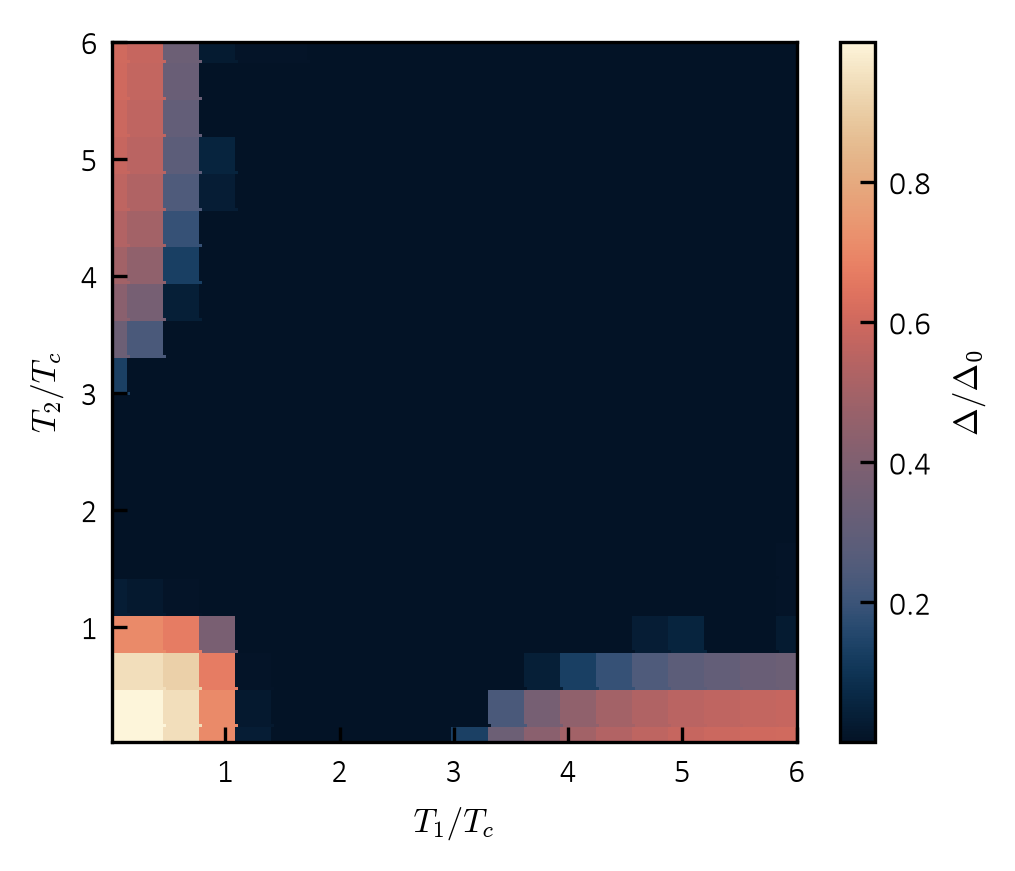

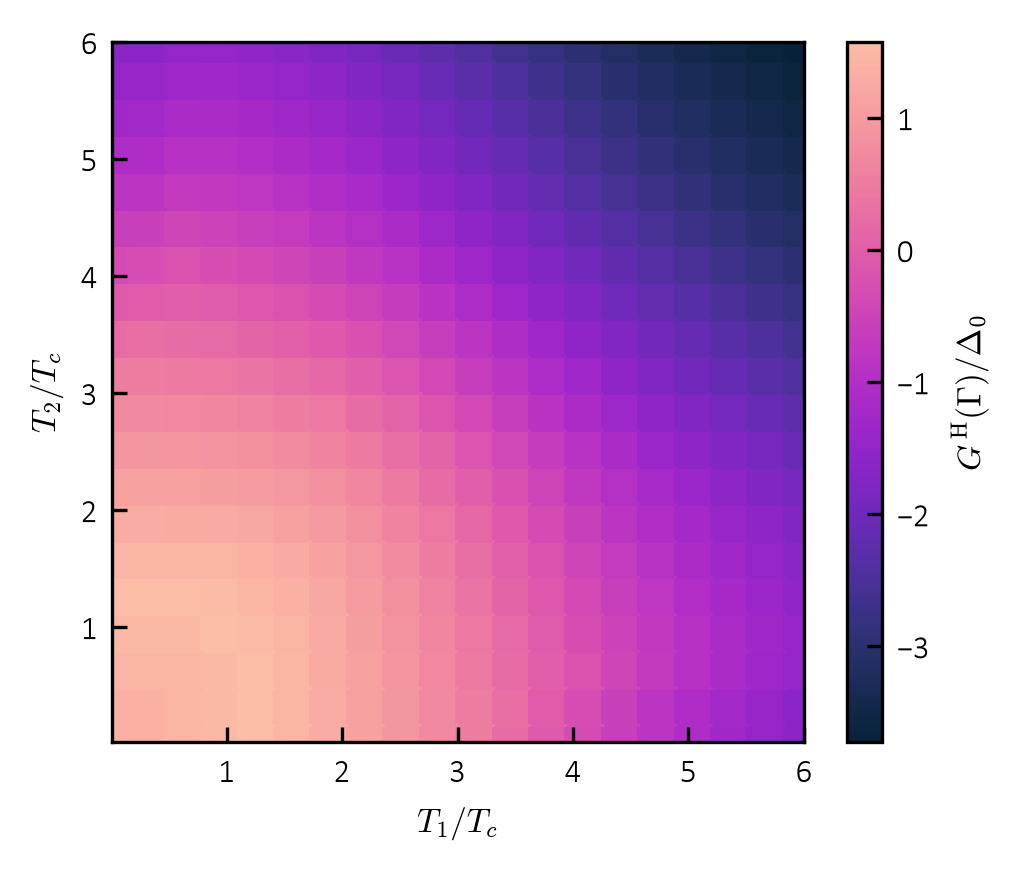

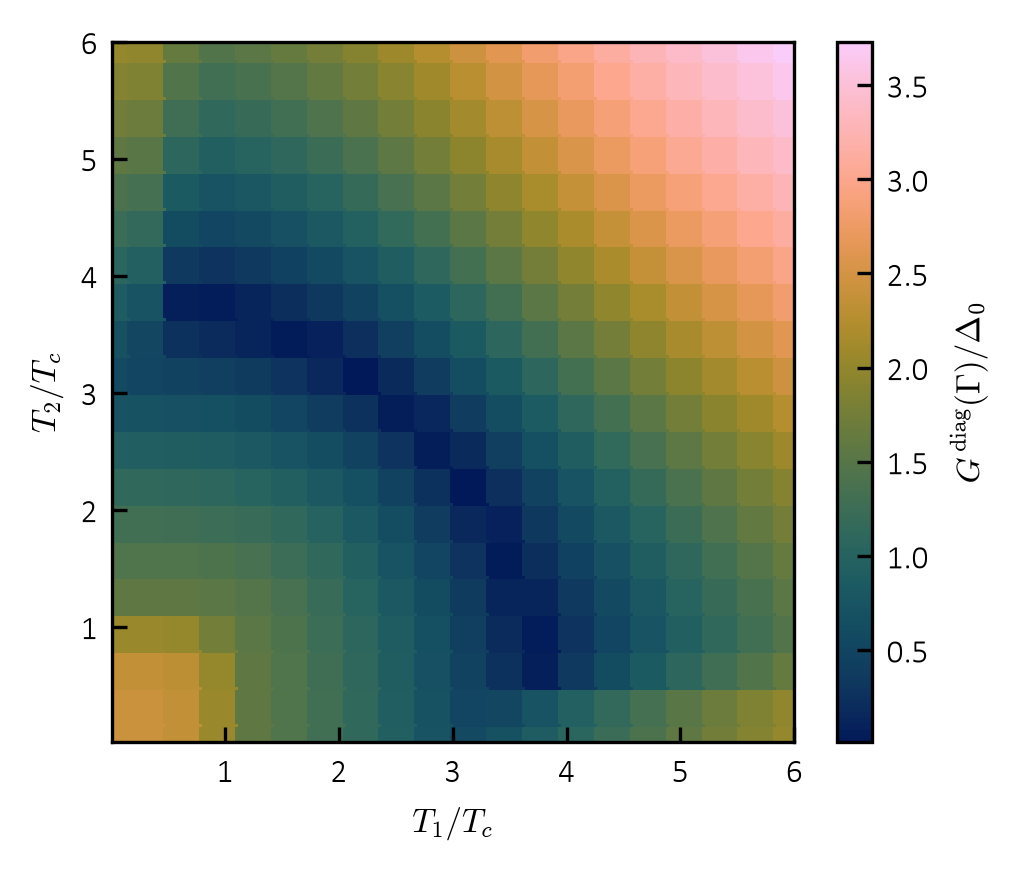

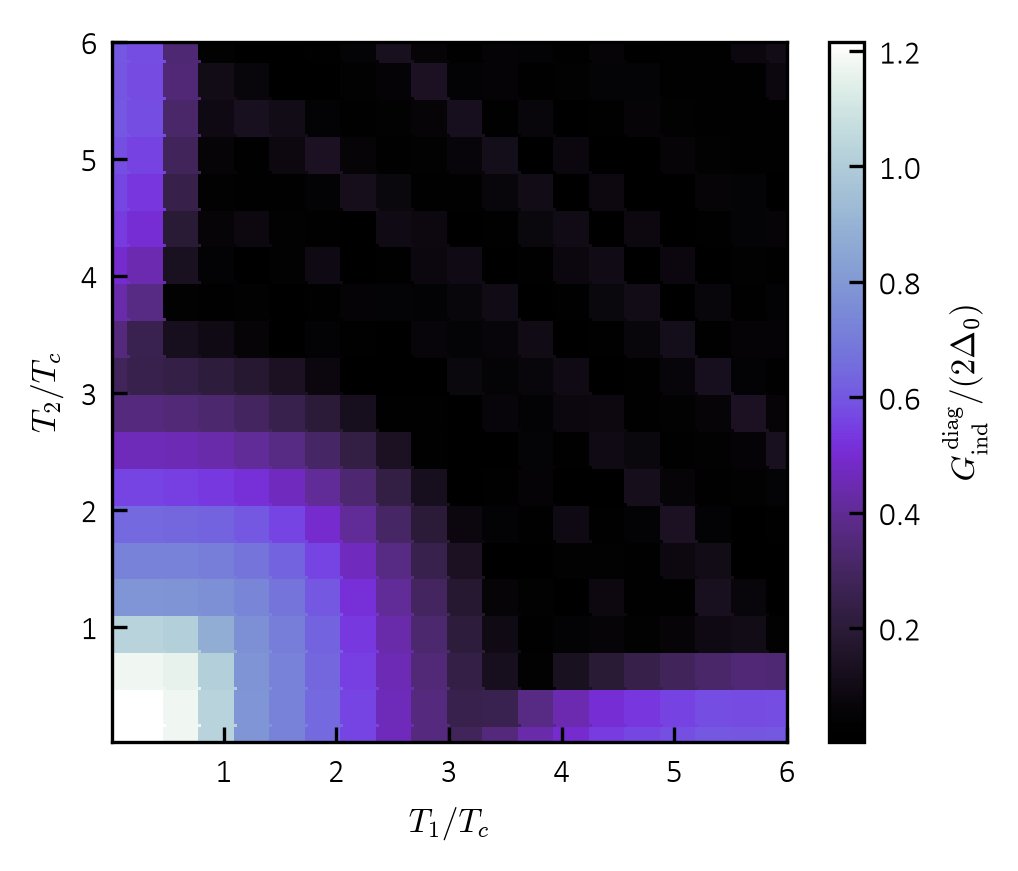

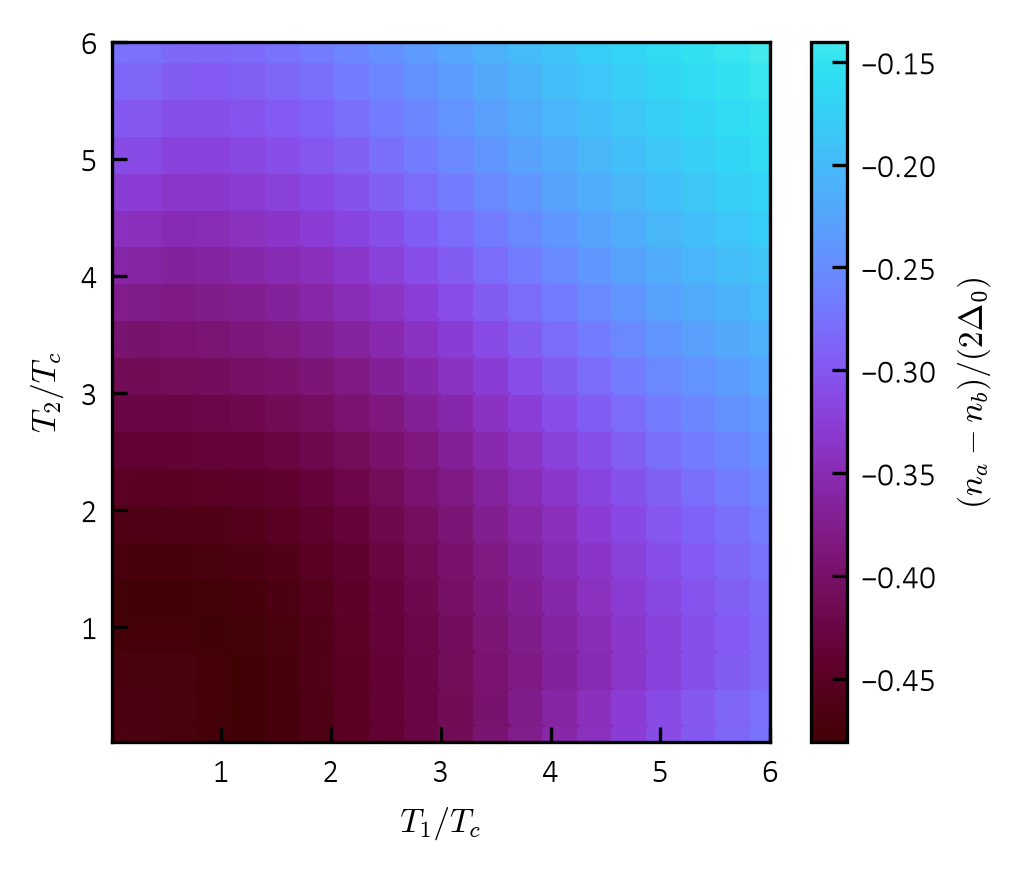

In [46]:
plot_maps(pt, tn, z, d0)

## Koda za eno izbrano tocko + analiza

In [50]:
T1_TC = 1000
T2_TC = 0.001
N_CONT = 1

st, bs, t1, t2, mu = solve_state(
    bdr, p, eq, op, T1_TC, T2_TC, tc, d0, m0, N_CONT
)

ep = {
    "dt": 0.05,
    "mix": [0.15, 0.15],
    "tol": 1.0e-6,
    "nmax": 20000,
    "chk": 10,
    "mf": False,
    "prog": True,
    **cfg.get("effective_temperature", {}),
}
sf = solve_teff(bdr, p, bs, st, t1, t2, mu, op, ep)

logger.info("T1/T_c = %.6g, T2/T_c = %.6g", T1_TC, T2_TC)
logger.info("Delta = %.8f, m = %.8f", st.d, st.m)
logger.info("beta_eff = %.8f, T_eff/T_c = %.8f", sf.beta, sf.t / tc)

Effective temperature:   0%|          | 0/20000 [00:00<?, ?it/s]

[19:52:05] [INFO    ] T1/T_c = 1000, T2/T_c = 0.001
[19:52:05] [INFO    ] Delta = 0.47956783, m = -0.22487977
[19:52:05] [INFO    ] beta_eff = 0.28884830, T_eff/T_c = 6.25480439


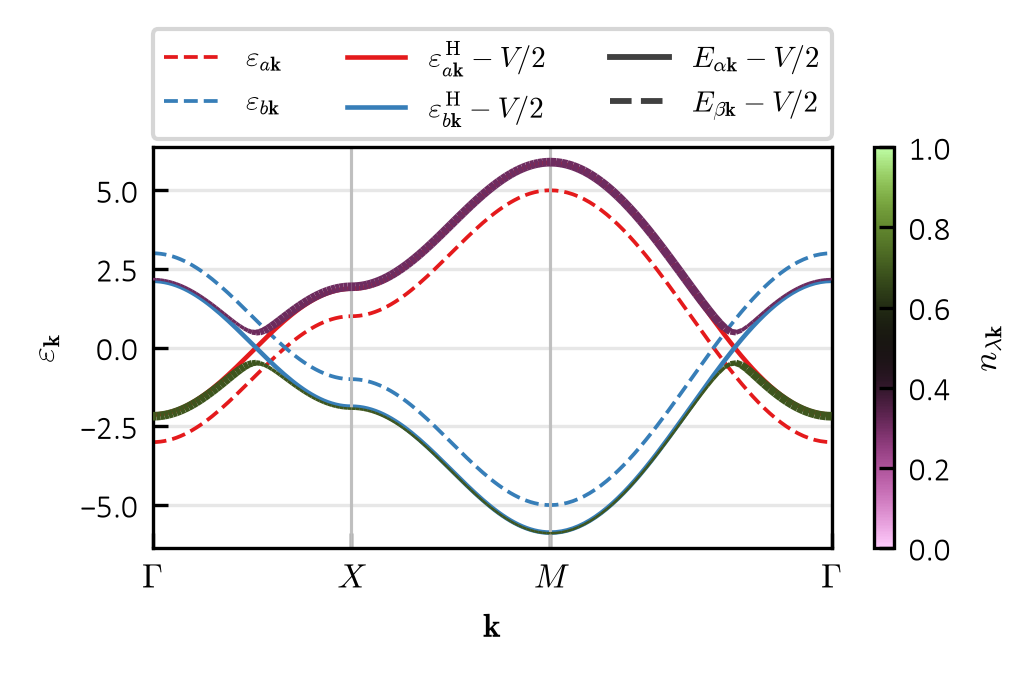

In [51]:
plot_dispersion(pt, bdr, st, mu)

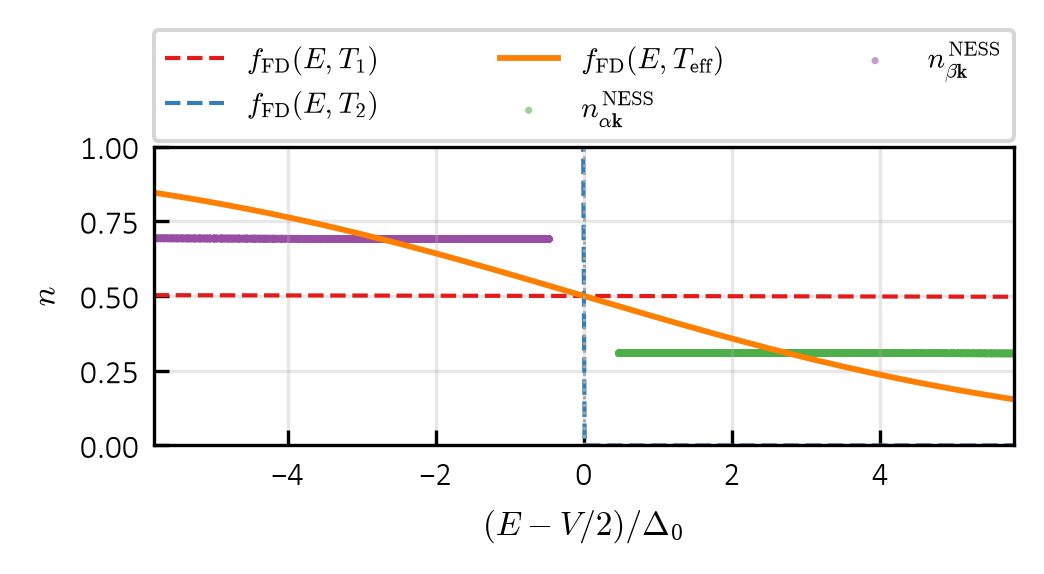

In [52]:
plot_energy(pt, st, sf, t1, t2, mu, d0)

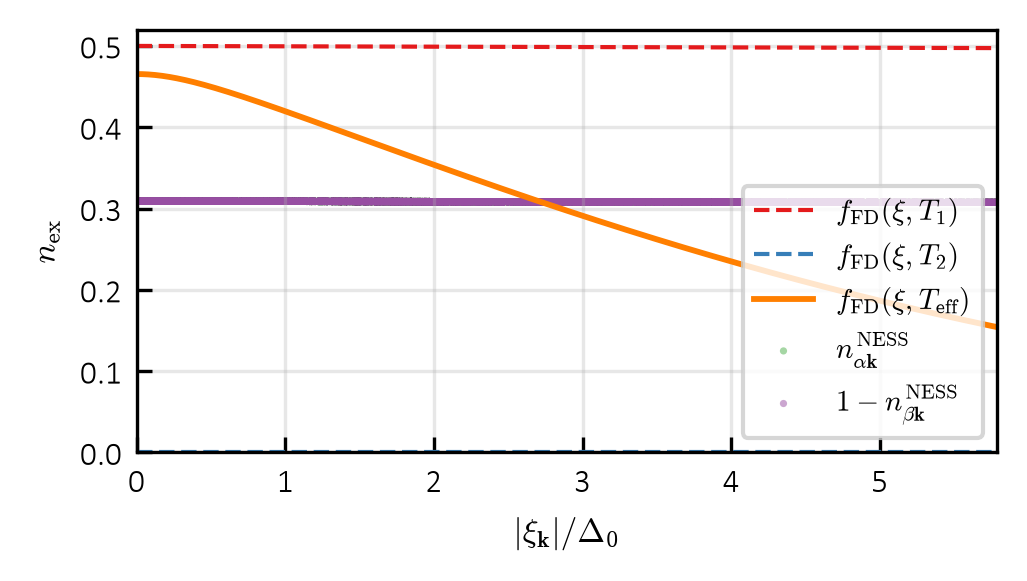

In [53]:
plot_xi(pt, bdr, p, eq, st, sf, t1, t2, d0)

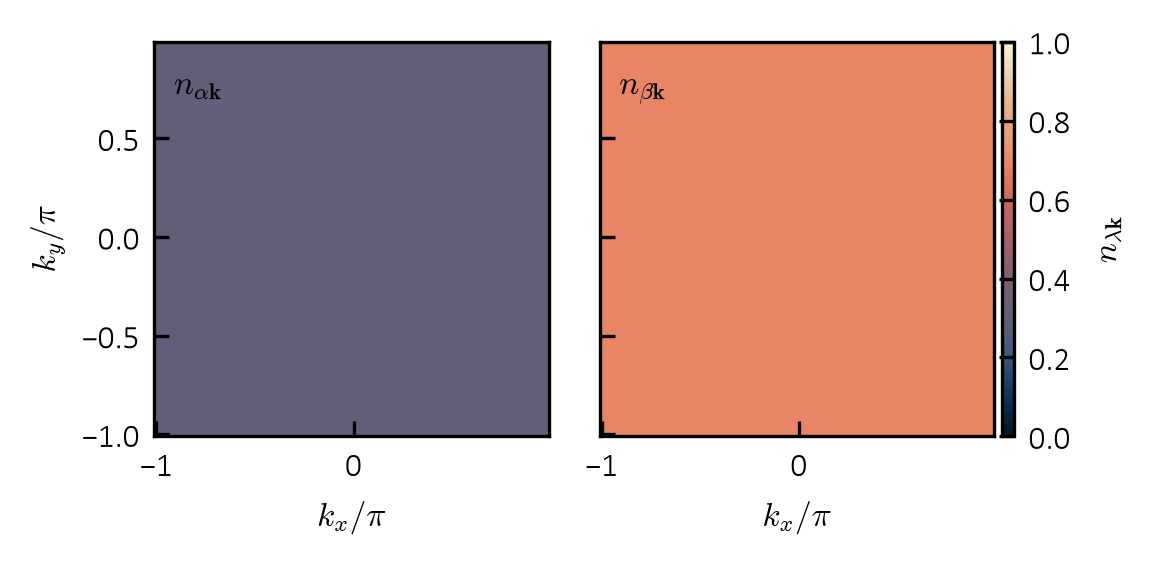

In [54]:
plot_bz(pt, bdr, st)